In [96]:
import pandas as pd

In [97]:
df_dispo = pd.read_csv("DisponibiliteAlimentaire_2017.csv",sep=",")

In [98]:
df_dispo.head()

,Code Domaine,Domaine,Code zone,Zone,Code Élément,Élément,Code Produit,Produit,Code année,Année,Unité,Valeur,Symbole,Description du Symbole
0,FBS,Nouveaux Bilans Alimentaire,2,Afghanistan,5511,Production,2511,Blé et produits,2017,2017,Milliers de tonnes,4281.0,S,Données standardisées
1,FBS,Nouveaux Bilans Alimentaire,2,Afghanistan,5611,Importations - Quantité,2511,Blé et produits,2017,2017,Milliers de tonnes,2302.0,S,Données standardisées
2,FBS,Nouveaux Bilans Alimentaire,2,Afghanistan,5072,Variation de stock,2511,Blé et produits,2017,2017,Milliers de tonnes,-119.0,S,Données standardisées
3,FBS,Nouveaux Bilans Alimentaire,2,Afghanistan,5911,Exportations - Quantité,2511,Blé et produits,2017,2017,Milliers de tonnes,0.0,S,Données standardisées
4,FBS,Nouveaux Bilans Alimentaire,2,Afghanistan,5301,Disponibilité intérieure,2511,Blé et produits,2017,2017,Milliers de tonnes,6701.0,S,Données standardisées


In [99]:
df_dispo.nunique()

Code Domaine                 1
Domaine                      1
Code zone                  174
Zone                       174
Code Élément                17
Élément                     17
Code Produit                98
Produit                     98
Code année                   1
Année                        1
Unité                        4
Valeur                    7250
Symbole                      2
Description du Symbole       2
dtype: int64

In [100]:
for col in df_dispo.columns:
    uniques = df_dispo[col].unique()[:20].tolist()
    total = df_dispo[col].nunique()
    suffix = f"... (+{total - 20} autres)" if total > 20 else ""
    print(f"\n{col} ({total} valeurs uniques) :")
    print(uniques, suffix)



Code Domaine (1 valeurs uniques) :
['FBS'] 

Domaine (1 valeurs uniques) :
['Nouveaux Bilans Alimentaire'] 

Code zone (174 valeurs uniques) :
[2, 202, 3, 4, 79, 7, 8, 194, 9, 1, 10, 11, 52, 12, 16, 14, 57, 255, 23, 53] ... (+154 autres)

Zone (174 valeurs uniques) :
['Afghanistan', 'Afrique du Sud', 'Albanie', 'Algérie', 'Allemagne', 'Angola', 'Antigua-et-Barbuda', 'Arabie saoudite', 'Argentine', 'Arménie', 'Australie', 'Autriche', 'Azerbaïdjan', 'Bahamas', 'Bangladesh', 'Barbade', 'Bélarus', 'Belgique', 'Belize', 'Bénin'] ... (+154 autres)

Code Élément (17 valeurs uniques) :
[5511, 5611, 5072, 5911, 5301, 5521, 5527, 5123, 5170, 5142, 645, 664, 674, 684, 5131, 5154, 5171] 

Élément (17 valeurs uniques) :
['Production', 'Importations - Quantité', 'Variation de stock', 'Exportations - Quantité', 'Disponibilité intérieure', 'Aliments pour animaux', 'Semences', 'Pertes', 'Résidus', 'Nourriture', 'Disponibilité alimentaire en quantité (kg/personne/an)', 'Disponibilité alimentaire (Kcal/

In [101]:
df_dispo = df_dispo.drop(columns=['Code Domaine','Domaine','Code zone','Code Élément','Code Produit','Code année','Symbole','Description du Symbole'])

In [102]:
df_dispo.isnull().sum()

Zone       0
Élément    0
Produit    0
Année      0
Unité      0
Valeur     0
dtype: int64

In [103]:
df_dispo.head()

,Zone,Élément,Produit,Année,Unité,Valeur
0,Afghanistan,Production,Blé et produits,2017,Milliers de tonnes,4281.0
1,Afghanistan,Importations - Quantité,Blé et produits,2017,Milliers de tonnes,2302.0
2,Afghanistan,Variation de stock,Blé et produits,2017,Milliers de tonnes,-119.0
3,Afghanistan,Exportations - Quantité,Blé et produits,2017,Milliers de tonnes,0.0
4,Afghanistan,Disponibilité intérieure,Blé et produits,2017,Milliers de tonnes,6701.0


In [104]:
df_dispo['Produit'].unique()

array(['Blé et produits', 'Riz et produits', 'Orge et produits',
       'Maïs et produits', 'Seigle et produits', 'Avoine',
       'Millet et produits', 'Sorgho et produits', 'Céréales Autres',
       'Pommes de Terre et produits', 'Ignames', 'Racines nda',
       'Sucre canne', 'Sucre betterave', 'Sucre Eq Brut',
       'Edulcorants Autres', 'Miel', 'Haricots', 'Pois',
       'Légumineuses Autres et produits', 'Noix et produits', 'Soja',
       'Arachides Decortiquees', 'Graines de tournesol',
       'Graines Colza/Moutarde', 'Graines de coton', 'Coco (Incl Coprah)',
       'Sésame', 'Olives', 'Plantes Oleiferes Autre', 'Huile de Soja',
       "Huile d'Arachide", 'Huile de Tournesol',
       'Huile de Colza&Moutarde', 'Huile Graines de Coton',
       'Huile de Palmistes', 'Huile de Palme', 'Huile de Coco',
       'Huile de Sésame', "Huile d'Olive", 'Huile de Son de Riz',
       'Huile de Germe de Maïs', 'Huil Plantes Oleif Autr',
       'Tomates et produits', 'Oignons', 'Légumes Autre

In [105]:
df_dispo = df_dispo[df_dispo['Produit']=='Viande de Volailles']

In [106]:
df_dispo = df_dispo.drop(columns=['Produit'])

In [107]:
for element in df_dispo['Élément'].unique():
    print(f"\n{'='*60}")
    print(f"Élément : {element}")
    print('='*60)
    print(df_dispo[df_dispo['Élément'] == element].head(5))


Élément : Production
                Zone     Élément  Année               Unité  Valeur
651      Afghanistan  Production   2017  Milliers de tonnes    28.0
1704  Afrique du Sud  Production   2017  Milliers de tonnes  1667.0
2713         Albanie  Production   2017  Milliers de tonnes    13.0
3772         Algérie  Production   2017  Milliers de tonnes   275.0
4873       Allemagne  Production   2017  Milliers de tonnes  1514.0

Élément : Importations - Quantité
                Zone                  Élément  Année               Unité  \
652      Afghanistan  Importations - Quantité   2017  Milliers de tonnes   
1705  Afrique du Sud  Importations - Quantité   2017  Milliers de tonnes   
2714         Albanie  Importations - Quantité   2017  Milliers de tonnes   
3773         Algérie  Importations - Quantité   2017  Milliers de tonnes   
4874       Allemagne  Importations - Quantité   2017  Milliers de tonnes   

      Valeur  
652     29.0  
1705   514.0  
2714    38.0  
3773     2.0  
487

In [108]:
# Éléments à garder :
a_garder = ['Production','Importations - Quantité','Disponibilité intérieure','Pertes','Nourriture','Disponibilité alimentaire en quantité (kg/personne/an)','Exportations - Quantité']

In [109]:
df_dispo = df_dispo[df_dispo['Élément'].isin(a_garder)]

In [110]:
df_dispo

,Zone,Élément,Année,Unité,Valeur
651,Afghanistan,Production,2017,Milliers de tonnes,28.00
652,Afghanistan,Importations - Quantité,2017,Milliers de tonnes,29.00
654,Afghanistan,Disponibilité intérieure,2017,Milliers de tonnes,57.00
655,Afghanistan,Pertes,2017,Milliers de tonnes,2.00
657,Afghanistan,Nourriture,2017,Milliers de tonnes,55.00
...,...,...,...,...,...
176389,Zimbabwe,Importations - Quantité,2017,Milliers de tonnes,6.00
176391,Zimbabwe,Disponibilité intérieure,2017,Milliers de tonnes,76.00
176392,Zimbabwe,Pertes,2017,Milliers de tonnes,3.00
176396,Zimbabwe,Nourriture,2017,Milliers de tonnes,67.00


In [111]:
df_dispo = df_dispo.pivot_table(
    index=['Zone', 'Année'], 
    columns=['Élément', 'Unité'], 
    values='Valeur',
    fill_value=0
).reset_index()

df_dispo.columns = [
    'Zone',
    'Année',
    'Dispo_kg_personne_an',
    'Dispo_interieure_kt',
    'Exportations_kt',
    'Importations_kt',
    'Nourriture_kt',
    'Pertes_kt',
    'Production_kt'
]

In [112]:
df_dispo

,Zone,Année,Dispo_kg_personne_an,Dispo_interieure_kt,Exportations_kt,Importations_kt,Nourriture_kt,Pertes_kt,Production_kt
0,Afghanistan,2017,1.53,57.0,0.0,29.0,55.0,2.0,28.0
1,Afrique du Sud,2017,35.69,2118.0,63.0,514.0,2035.0,83.0,1667.0
2,Albanie,2017,16.36,47.0,0.0,38.0,47.0,0.0,13.0
3,Algérie,2017,6.38,277.0,0.0,2.0,264.0,13.0,275.0
4,Allemagne,2017,19.47,1739.0,646.0,842.0,1609.0,0.0,1514.0
...,...,...,...,...,...,...,...,...,...
167,Émirats arabes unis,2017,43.47,412.0,94.0,433.0,412.0,0.0,48.0
168,Équateur,2017,19.31,341.0,0.0,0.0,324.0,17.0,340.0
169,États-Unis d'Amérique,2017,55.68,18266.0,3692.0,123.0,18100.0,0.0,21914.0
170,Éthiopie,2017,0.13,14.0,0.0,1.0,14.0,1.0,14.0


In [113]:
df_pib = pd.read_csv('FAOSTAT_data_fr_4-12-2026.csv',sep=',')

In [114]:
df_pib.head()

,Code Domaine,Domaine,Code zone (M49),Zone,Code Élément,Élément,Code Produit,Produit,Code année,Année,Unité,Valeur,Symbole,Description du Symbole,Note
0,MK,Indicateurs macro,4,Afghanistan,6110,Valeur US$,22008,Produit Intérieur Brut,2017,2017,Millions d’USD,19034.302820,X,Chiffre de source externe,NaN
1,MK,Indicateurs macro,4,Afghanistan,6129,Croissance annuelle US$,22008,Produit Intérieur Brut,2017,2017,%,4.444345,X,Chiffre de source externe,NaN
2,MK,Indicateurs macro,710,Afrique du Sud,6110,Valeur US$,22008,Produit Intérieur Brut,2017,2017,Millions d’USD,381136.716379,X,Chiffre de source externe,NaN
3,MK,Indicateurs macro,710,Afrique du Sud,6129,Croissance annuelle US$,22008,Produit Intérieur Brut,2017,2017,%,17.791964,X,Chiffre de source externe,NaN
4,MK,Indicateurs macro,8,Albanie,6110,Valeur US$,22008,Produit Intérieur Brut,2017,2017,Millions d’USD,13019.731318,X,Chiffre de source externe,NaN


In [115]:
df_pib.nunique()

Code Domaine                1
Domaine                     1
Code zone (M49)           210
Zone                      210
Code Élément                2
Élément                     2
Code Produit                1
Produit                     1
Code année                  1
Année                       1
Unité                       2
Valeur                    420
Symbole                     1
Description du Symbole      1
Note                        0
dtype: int64

In [116]:
for col in df_pib.columns:
    uniques = df_pib[col].unique()[:20].tolist()
    total = df_pib[col].nunique()
    suffix = f"... (+{total - 20} autres)" if total > 20 else ""
    print(f"\n{col} ({total} valeurs uniques) :")
    print(uniques, suffix)


Code Domaine (1 valeurs uniques) :
['MK'] 

Domaine (1 valeurs uniques) :
['Indicateurs macro'] 

Code zone (M49) (210 valeurs uniques) :
[4, 710, 8, 12, 276, 20, 24, 660, 28, 682, 32, 51, 533, 36, 40, 31, 44, 48, 50, 52] ... (+190 autres)

Zone (210 valeurs uniques) :
['Afghanistan', 'Afrique du Sud', 'Albanie', 'Algérie', 'Allemagne', 'Andorre', 'Angola', 'Anguilla', 'Antigua-et-Barbuda', 'Arabie saoudite', 'Argentine', 'Arménie', 'Aruba', 'Australie', 'Autriche', 'Azerbaïdjan', 'Bahamas', 'Bahreïn', 'Bangladesh', 'Barbade'] ... (+190 autres)

Code Élément (2 valeurs uniques) :
[6110, 6129] 

Élément (2 valeurs uniques) :
['Valeur US$', 'Croissance annuelle US$'] 

Code Produit (1 valeurs uniques) :
[22008] 

Produit (1 valeurs uniques) :
['Produit Intérieur Brut'] 

Code année (1 valeurs uniques) :
[2017] 

Année (1 valeurs uniques) :
[2017] 

Unité (2 valeurs uniques) :
['Millions d’USD', '%'] 

Valeur (420 valeurs uniques) :
[19034.30282, 4.444345, 381136.716379, 17.791964, 13019

In [117]:
df_pib = df_pib.drop(columns=['Code Domaine','Domaine','Code zone (M49)','Code Élément','Code Produit','Produit','Code année','Symbole','Description du Symbole','Note'])

In [118]:
df_pib.isnull().sum()

Zone       0
Élément    0
Année      0
Unité      0
Valeur     0
dtype: int64

In [119]:
df_pib.head()

,Zone,Élément,Année,Unité,Valeur
0,Afghanistan,Valeur US$,2017,Millions d’USD,19034.302820
1,Afghanistan,Croissance annuelle US$,2017,%,4.444345
2,Afrique du Sud,Valeur US$,2017,Millions d’USD,381136.716379
3,Afrique du Sud,Croissance annuelle US$,2017,%,17.791964
4,Albanie,Valeur US$,2017,Millions d’USD,13019.731318


In [120]:
df_pib = df_pib.pivot_table(
    index=['Zone', 'Année'], 
    columns=['Élément', 'Unité'], 
    values='Valeur',
    fill_value=0
).reset_index()

In [121]:
df_pib.columns = [
    'Zone',
    'Année',
    'Croissance_annuelle_PIB_%',
    'PIB_M$',
]

In [122]:
df_pib

,Zone,Année,Croissance_annuelle_PIB_%,PIB_M$
0,Afghanistan,2017,4.444345,1.903430e+04
1,Afrique du Sud,2017,17.791964,3.811367e+05
2,Albanie,2017,9.767331,1.301973e+04
3,Algérie,2017,6.287893,1.700970e+05
4,Allemagne,2017,6.368624,3.763092e+06
...,...,...,...,...
205,Îles Cook,2017,11.537810,3.456090e+02
206,Îles Marshall,2017,5.971253,2.127012e+02
207,Îles Salomon,2017,6.546216,1.469790e+03
208,Îles Turques-et-Caïques,2017,-0.976995,1.022365e+03


In [123]:
df_importations = pd.read_csv('Importations.csv',sep=',')

In [124]:
df_importations.head()

,Code Domaine,Domaine,Code zone (M49),Zone,Code Élément,Élément,Code Produit (CPC),Produit,Code année,Année,Unité,Valeur,Symbole,Description du Symbole,Note
0,TCL,Cultures et produits animaux,4,Afghanistan,5609,Importations - quantité,2151,Poulets,2017,2017,1000 têtes,18970,A,Chiffre officiel,NaN
1,TCL,Cultures et produits animaux,4,Afghanistan,5622,Importations - valeur,2151,Poulets,2017,2017,1000 USD,26227,A,Chiffre officiel,NaN
2,TCL,Cultures et produits animaux,710,Afrique du Sud,5609,Importations - quantité,2151,Poulets,2017,2017,1000 têtes,397,A,Chiffre officiel,NaN
3,TCL,Cultures et produits animaux,710,Afrique du Sud,5622,Importations - valeur,2151,Poulets,2017,2017,1000 USD,7394,A,Chiffre officiel,NaN
4,TCL,Cultures et produits animaux,710,Afrique du Sud,5909,Exportations - quantité,2151,Poulets,2017,2017,1000 têtes,6090,A,Chiffre officiel,NaN


In [125]:
df_importations.nunique()

Code Domaine                1
Domaine                     1
Code zone (M49)           187
Zone                      187
Code Élément                4
Élément                     4
Code Produit (CPC)          1
Produit                     1
Code année                  1
Année                       1
Unité                       2
Valeur                    485
Symbole                     4
Description du Symbole      4
Note                        1
dtype: int64

In [126]:
for col in df_importations.columns:
    uniques = df_importations[col].unique()[:20].tolist()
    total = df_importations[col].nunique()
    suffix = f"... (+{total - 20} autres)" if total > 20 else ""
    print(f"\n{col} ({total} valeurs uniques) :")
    print(uniques, suffix)


Code Domaine (1 valeurs uniques) :
['TCL'] 

Domaine (1 valeurs uniques) :
['Cultures et produits animaux'] 

Code zone (M49) (187 valeurs uniques) :
[4, 710, 8, 12, 276, 24, 28, 682, 32, 51, 36, 40, 31, 44, 48, 50, 52, 112, 56, 84] ... (+167 autres)

Zone (187 valeurs uniques) :
['Afghanistan', 'Afrique du Sud', 'Albanie', 'Algérie', 'Allemagne', 'Angola', 'Antigua-et-Barbuda', 'Arabie saoudite', 'Argentine', 'Arménie', 'Australie', 'Autriche', 'Azerbaïdjan', 'Bahamas', 'Bahreïn', 'Bangladesh', 'Barbade', 'Bélarus', 'Belgique', 'Belize'] ... (+167 autres)

Code Élément (4 valeurs uniques) :
[5609, 5622, 5909, 5922] 

Élément (4 valeurs uniques) :
['Importations - quantité', 'Importations - valeur', 'Exportations - quantité', 'Exportations - valeur'] 

Code Produit (CPC) (1 valeurs uniques) :
[2151] 

Produit (1 valeurs uniques) :
['Poulets'] 

Code année (1 valeurs uniques) :
[2017] 

Année (1 valeurs uniques) :
[2017] 

Unité (2 valeurs uniques) :
['1000 têtes', '1000 USD'] 

Valeur

In [127]:
df_importations = df_importations.drop(columns=['Code Domaine','Domaine','Code zone (M49)','Code Élément','Code Produit (CPC)','Produit','Code année','Symbole','Description du Symbole','Note'])

In [128]:
df_importations.isnull().sum()

Zone       0
Élément    0
Année      0
Unité      0
Valeur     0
dtype: int64

In [129]:
df_importations.head()

,Zone,Élément,Année,Unité,Valeur
0,Afghanistan,Importations - quantité,2017,1000 têtes,18970
1,Afghanistan,Importations - valeur,2017,1000 USD,26227
2,Afrique du Sud,Importations - quantité,2017,1000 têtes,397
3,Afrique du Sud,Importations - valeur,2017,1000 USD,7394
4,Afrique du Sud,Exportations - quantité,2017,1000 têtes,6090


In [130]:
df_importations = df_importations.pivot_table(
    index=['Zone', 'Année'], 
    columns=['Élément', 'Unité'], 
    values='Valeur',
    fill_value=0
).reset_index()

In [131]:
df_importations.columns = [
    'Zone',
    'Année',
    'Export_kTetes',
    'Export_k$',
    'Import_kTetes',
    'Import_k$'
]

In [132]:
df_importations

,Zone,Année,Export_kTetes,Export_k$,Import_kTetes,Import_k$
0,Afghanistan,2017,0.0,0.0,18970.0,26227.0
1,Afrique du Sud,2017,6090.0,7992.0,397.0,7394.0
2,Albanie,2017,0.0,0.0,4572.0,3266.0
3,Algérie,2017,0.0,0.0,195.0,19051.0
4,Allemagne,2017,328450.0,654322.0,185661.0,193759.0
...,...,...,...,...,...,...
182,Érythrée,2017,79.0,177.0,141.0,287.0
183,États-Unis d'Amérique,2017,68817.0,190166.0,4872.0,8580.0
184,Éthiopie,2017,0.0,0.0,2.0,91.0
185,Îles Cook,2017,0.0,0.0,0.0,2.0


In [133]:
df_pop = pd.read_csv('Population_2000_2018.csv',sep=',')

In [134]:
df_pop.head()

,Code Domaine,Domaine,Code zone,Zone,Code Élément,Élément,Code Produit,Produit,Code année,Année,Unité,Valeur,Symbole,Description du Symbole,Note
0,OA,Séries temporelles annuelles,2,Afghanistan,511,Population totale,3010,Population-Estimations,2000,2000,1000 personnes,20779.953,X,Sources internationales sûres,NaN
1,OA,Séries temporelles annuelles,2,Afghanistan,511,Population totale,3010,Population-Estimations,2001,2001,1000 personnes,21606.988,X,Sources internationales sûres,NaN
2,OA,Séries temporelles annuelles,2,Afghanistan,511,Population totale,3010,Population-Estimations,2002,2002,1000 personnes,22600.770,X,Sources internationales sûres,NaN
3,OA,Séries temporelles annuelles,2,Afghanistan,511,Population totale,3010,Population-Estimations,2003,2003,1000 personnes,23680.871,X,Sources internationales sûres,NaN
4,OA,Séries temporelles annuelles,2,Afghanistan,511,Population totale,3010,Population-Estimations,2004,2004,1000 personnes,24726.684,X,Sources internationales sûres,NaN


In [135]:
for col in df_pop.columns:
    uniques = df_pop[col].unique()[:20].tolist()
    total = df_pop[col].nunique()
    suffix = f"... (+{total - 20} autres)" if total > 20 else ""
    print(f"\n{col} ({total} valeurs uniques) :")
    print(uniques, suffix)


Code Domaine (1 valeurs uniques) :
['OA'] 

Domaine (1 valeurs uniques) :
['Séries temporelles annuelles'] 

Code zone (238 valeurs uniques) :
[2, 202, 3, 4, 79, 6, 7, 258, 8, 151, 194, 9, 1, 22, 10, 11, 52, 12, 13, 16] ... (+218 autres)

Zone (238 valeurs uniques) :
['Afghanistan', 'Afrique du Sud', 'Albanie', 'Algérie', 'Allemagne', 'Andorre', 'Angola', 'Anguilla', 'Antigua-et-Barbuda', 'Antilles néerlandaises (ex)', 'Arabie saoudite', 'Argentine', 'Arménie', 'Aruba', 'Australie', 'Autriche', 'Azerbaïdjan', 'Bahamas', 'Bahreïn', 'Bangladesh'] ... (+218 autres)

Code Élément (1 valeurs uniques) :
[511] 

Élément (1 valeurs uniques) :
['Population totale'] 

Code Produit (1 valeurs uniques) :
[3010] 

Produit (1 valeurs uniques) :
['Population-Estimations'] 

Code année (19 valeurs uniques) :
[2000, 2001, 2002, 2003, 2004, 2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018] 

Année (19 valeurs uniques) :
[2000, 2001, 2002, 2003, 2004, 2005, 2006, 2007, 

In [136]:
df_pop = df_pop.drop(columns=['Code Domaine','Domaine','Code zone','Code Élément','Élément','Code Produit','Produit','Code année','Symbole','Description du Symbole','Note'])

In [137]:
df_pop

,Zone,Année,Unité,Valeur
0,Afghanistan,2000,1000 personnes,20779.953
1,Afghanistan,2001,1000 personnes,21606.988
2,Afghanistan,2002,1000 personnes,22600.770
3,Afghanistan,2003,1000 personnes,23680.871
4,Afghanistan,2004,1000 personnes,24726.684
...,...,...,...,...
4406,Zimbabwe,2014,1000 personnes,13586.707
4407,Zimbabwe,2015,1000 personnes,13814.629
4408,Zimbabwe,2016,1000 personnes,14030.331
4409,Zimbabwe,2017,1000 personnes,14236.595


In [138]:
df_pop['Valeur']=df_pop['Valeur']*1000

In [139]:
df_pop = df_pop.drop(columns=['Unité'])

In [140]:
df_pop.head(20)

,Zone,Année,Valeur
0,Afghanistan,2000,20779953.0
1,Afghanistan,2001,21606988.0
2,Afghanistan,2002,22600770.0
3,Afghanistan,2003,23680871.0
4,Afghanistan,2004,24726684.0
5,Afghanistan,2005,25654277.0
6,Afghanistan,2006,26433049.0
7,Afghanistan,2007,27100536.0
8,Afghanistan,2008,27722276.0
9,Afghanistan,2009,28394813.0


In [141]:
df_pop = df_pop[df_pop['Année'].isin([2017,2016,2015,2014,2013])]

In [142]:
df_pop.head(20)

,Zone,Année,Valeur
13,Afghanistan,2013,32269589.0
14,Afghanistan,2014,33370794.0
15,Afghanistan,2015,34413603.0
16,Afghanistan,2016,35383032.0
17,Afghanistan,2017,36296113.0
32,Afrique du Sud,2013,53687121.0
33,Afrique du Sud,2014,54544186.0
34,Afrique du Sud,2015,55386367.0
35,Afrique du Sud,2016,56207646.0
36,Afrique du Sud,2017,57009756.0


In [143]:
df_pop.isnull().sum()

Zone      0
Année     0
Valeur    0
dtype: int64

In [144]:
df_pop.columns = [
    'Zone','Année','Population'
]

In [145]:
df_pop = df_pop[df_pop['Année'].isin([2013,2017])]

In [146]:
df_pop_2013 = df_pop[df_pop['Année']==2013]
df_pop_2017 = df_pop[df_pop['Année']==2017]

In [147]:
df_pop_final = df_pop_2017.merge(df_pop_2013,on='Zone',how='left')

In [148]:
df_pop_final['croissance_5ans'] = (df_pop_final['Population_x']-df_pop_final['Population_y'])/df_pop_final['Population_y']

In [149]:
df_pop = df_pop_final[['Zone','Année_x','Population_x','croissance_5ans']]

In [150]:
df_pop.columns = ['Zone','Année','Population','croissance_pop_5ans']

In [151]:
df_pop

,Zone,Année,Population,croissance_pop_5ans
0,Afghanistan,2017,36296113.0,0.124778
1,Afrique du Sud,2017,57009756.0,0.061889
2,Albanie,2017,2884169.0,-0.006757
3,Algérie,2017,41389189.0,0.085187
4,Allemagne,2017,82658409.0,0.018282
...,...,...,...,...
231,Venezuela (République bolivarienne du),2017,29402484.0,-0.012711
232,Viet Nam,2017,94600648.0,0.042402
233,Yémen,2017,27834819.0,0.106879
234,Zambie,2017,16853599.0,0.129103


In [152]:
df_stab_pol = pd.read_csv('Stabilité politique 2017.csv',sep=',')

In [153]:
df_stab_pol.head()

,Code Domaine,Domaine,Code zone (M49),Zone,Code Élément,Élément,Code Produit,Produit,Code année,Année,Unité,Valeur,Symbole,Description du Symbole,Note
0,FS,Données de la sécurité alimentaire,4,Afghanistan,6125,Valeur,21032,Stabilité politique et absence de violence/ter...,2017,2017,NaN,-2.79,X,Chiffre de source externe,NaN
1,FS,Données de la sécurité alimentaire,710,Afrique du Sud,6125,Valeur,21032,Stabilité politique et absence de violence/ter...,2017,2017,NaN,-0.28,X,Chiffre de source externe,NaN
2,FS,Données de la sécurité alimentaire,8,Albanie,6125,Valeur,21032,Stabilité politique et absence de violence/ter...,2017,2017,NaN,0.37,X,Chiffre de source externe,NaN
3,FS,Données de la sécurité alimentaire,12,Algérie,6125,Valeur,21032,Stabilité politique et absence de violence/ter...,2017,2017,NaN,-0.92,X,Chiffre de source externe,NaN
4,FS,Données de la sécurité alimentaire,276,Allemagne,6125,Valeur,21032,Stabilité politique et absence de violence/ter...,2017,2017,NaN,0.57,X,Chiffre de source externe,NaN


In [154]:
for col in df_stab_pol.columns:
    uniques = df_stab_pol[col].unique()[:20].tolist()
    total = df_stab_pol[col].nunique()
    suffix = f"... (+{total - 20} autres)" if total > 20 else ""
    print(f"\n{col} ({total} valeurs uniques) :")
    print(uniques, suffix)


Code Domaine (1 valeurs uniques) :
['FS'] 

Domaine (1 valeurs uniques) :
['Données de la sécurité alimentaire'] 

Code zone (M49) (195 valeurs uniques) :
[4, 710, 8, 12, 276, 20, 24, 28, 682, 32, 51, 36, 40, 31, 44, 48, 50, 52, 112, 56] ... (+175 autres)

Zone (195 valeurs uniques) :
['Afghanistan', 'Afrique du Sud', 'Albanie', 'Algérie', 'Allemagne', 'Andorre', 'Angola', 'Antigua-et-Barbuda', 'Arabie saoudite', 'Argentine', 'Arménie', 'Australie', 'Autriche', 'Azerbaïdjan', 'Bahamas', 'Bahreïn', 'Bangladesh', 'Barbade', 'Bélarus', 'Belgique'] ... (+175 autres)

Code Élément (1 valeurs uniques) :
[6125] 

Élément (1 valeurs uniques) :
['Valeur'] 

Code Produit (1 valeurs uniques) :
[21032] 

Produit (1 valeurs uniques) :
['Stabilité politique et absence de violence/terrorisme (indice)'] 

Code année (1 valeurs uniques) :
[2017] 

Année (1 valeurs uniques) :
[2017] 

Unité (0 valeurs uniques) :
[nan] 

Valeur (148 valeurs uniques) :
[-2.79, -0.28, 0.37, -0.92, 0.57, 1.39, -0.39, 0.73,

In [155]:
df_stab_pol = df_stab_pol.drop(columns=['Code Domaine','Domaine','Code zone (M49)','Code Élément','Élément','Code Produit','Produit','Code année','Unité','Symbole','Description du Symbole','Note'])

In [156]:
df_stab_pol.isnull().sum()

Zone      0
Année     0
Valeur    0
dtype: int64

In [157]:
df_stab_pol.columns = ['Zone','Année','Stabilité politique']

In [158]:
df_stab_pol.head()

,Zone,Année,Stabilité politique
0,Afghanistan,2017,-2.79
1,Afrique du Sud,2017,-0.28
2,Albanie,2017,0.37
3,Algérie,2017,-0.92
4,Allemagne,2017,0.57


In [159]:
df_dispo.head()

,Zone,Année,Dispo_kg_personne_an,Dispo_interieure_kt,Exportations_kt,Importations_kt,Nourriture_kt,Pertes_kt,Production_kt
0,Afghanistan,2017,1.53,57.0,0.0,29.0,55.0,2.0,28.0
1,Afrique du Sud,2017,35.69,2118.0,63.0,514.0,2035.0,83.0,1667.0
2,Albanie,2017,16.36,47.0,0.0,38.0,47.0,0.0,13.0
3,Algérie,2017,6.38,277.0,0.0,2.0,264.0,13.0,275.0
4,Allemagne,2017,19.47,1739.0,646.0,842.0,1609.0,0.0,1514.0


In [160]:
df_importations.head()

,Zone,Année,Export_kTetes,Export_k$,Import_kTetes,Import_k$
0,Afghanistan,2017,0.0,0.0,18970.0,26227.0
1,Afrique du Sud,2017,6090.0,7992.0,397.0,7394.0
2,Albanie,2017,0.0,0.0,4572.0,3266.0
3,Algérie,2017,0.0,0.0,195.0,19051.0
4,Allemagne,2017,328450.0,654322.0,185661.0,193759.0


In [161]:
df_pib.head()

,Zone,Année,Croissance_annuelle_PIB_%,PIB_M$
0,Afghanistan,2017,4.444345,1.903430e+04
1,Afrique du Sud,2017,17.791964,3.811367e+05
2,Albanie,2017,9.767331,1.301973e+04
3,Algérie,2017,6.287893,1.700970e+05
4,Allemagne,2017,6.368624,3.763092e+06


In [162]:
df_pop.head()

,Zone,Année,Population,croissance_pop_5ans
0,Afghanistan,2017,36296113.0,0.124778
1,Afrique du Sud,2017,57009756.0,0.061889
2,Albanie,2017,2884169.0,-0.006757
3,Algérie,2017,41389189.0,0.085187
4,Allemagne,2017,82658409.0,0.018282


In [163]:
from functools import reduce

# Liste de tes 5 DataFrames
dfs = [df_pop,df_dispo,df_importations,df_pib,df_stab_pol]

# Fusion sur Zone et Année
df_final = reduce(lambda left, right: left.merge(right, on=['Zone', 'Année'], how='outer'), dfs)


In [164]:
df_final

,Zone,Année,Population,croissance_pop_5ans,Dispo_kg_personne_an,Dispo_interieure_kt,Exportations_kt,Importations_kt,Nourriture_kt,Pertes_kt,Production_kt,Export_kTetes,Export_k$,Import_kTetes,Import_k$,Croissance_annuelle_PIB_%,PIB_M$,Stabilité politique
0,Afghanistan,2017,36296113.0,0.124778,1.53,57.0,0.0,29.0,55.0,2.0,28.0,0.0,0.0,18970.0,26227.0,4.444345,1.903430e+04,-2.79
1,Afrique du Sud,2017,57009756.0,0.061889,35.69,2118.0,63.0,514.0,2035.0,83.0,1667.0,6090.0,7992.0,397.0,7394.0,17.791964,3.811367e+05,-0.28
2,Albanie,2017,2884169.0,-0.006757,16.36,47.0,0.0,38.0,47.0,0.0,13.0,0.0,0.0,4572.0,3266.0,9.767331,1.301973e+04,0.37
3,Algérie,2017,41389189.0,0.085187,6.38,277.0,0.0,2.0,264.0,13.0,275.0,0.0,0.0,195.0,19051.0,6.287893,1.700970e+05,-0.92
4,Allemagne,2017,82658409.0,0.018282,19.47,1739.0,646.0,842.0,1609.0,0.0,1514.0,328450.0,654322.0,185661.0,193759.0,6.368624,3.763092e+06,0.57
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
235,Îles Salomon,2017,636039.0,0.113249,4.45,3.0,0.0,6.0,3.0,0.0,0.0,NaN,NaN,NaN,NaN,6.546216,1.469790e+03,0.19
236,Îles Turques-et-Caïques,2017,37115.0,0.068642,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.976995,1.022365e+03,NaN
237,Îles Vierges américaines,2017,104751.0,-0.005242,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
238,Îles Vierges britanniques,2017,29577.0,0.025306,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-6.834640,1.309700e+03,NaN


In [165]:
df_final = df_final.dropna()

In [166]:
df_final.isnull().sum()

Zone                         0
Année                        0
Population                   0
croissance_pop_5ans          0
Dispo_kg_personne_an         0
Dispo_interieure_kt          0
Exportations_kt              0
Importations_kt              0
Nourriture_kt                0
Pertes_kt                    0
Production_kt                0
Export_kTetes                0
Export_k$                    0
Import_kTetes                0
Import_k$                    0
Croissance_annuelle_PIB_%    0
PIB_M$                       0
Stabilité politique          0
dtype: int64

In [167]:
df_final.head()

,Zone,Année,Population,croissance_pop_5ans,Dispo_kg_personne_an,Dispo_interieure_kt,Exportations_kt,Importations_kt,Nourriture_kt,Pertes_kt,Production_kt,Export_kTetes,Export_k$,Import_kTetes,Import_k$,Croissance_annuelle_PIB_%,PIB_M$,Stabilité politique
0,Afghanistan,2017,36296113.0,0.124778,1.53,57.0,0.0,29.0,55.0,2.0,28.0,0.0,0.0,18970.0,26227.0,4.444345,1.903430e+04,-2.79
1,Afrique du Sud,2017,57009756.0,0.061889,35.69,2118.0,63.0,514.0,2035.0,83.0,1667.0,6090.0,7992.0,397.0,7394.0,17.791964,3.811367e+05,-0.28
2,Albanie,2017,2884169.0,-0.006757,16.36,47.0,0.0,38.0,47.0,0.0,13.0,0.0,0.0,4572.0,3266.0,9.767331,1.301973e+04,0.37
3,Algérie,2017,41389189.0,0.085187,6.38,277.0,0.0,2.0,264.0,13.0,275.0,0.0,0.0,195.0,19051.0,6.287893,1.700970e+05,-0.92
4,Allemagne,2017,82658409.0,0.018282,19.47,1739.0,646.0,842.0,1609.0,0.0,1514.0,328450.0,654322.0,185661.0,193759.0,6.368624,3.763092e+06,0.57


In [168]:
df_final

,Zone,Année,Population,croissance_pop_5ans,Dispo_kg_personne_an,Dispo_interieure_kt,Exportations_kt,Importations_kt,Nourriture_kt,Pertes_kt,Production_kt,Export_kTetes,Export_k$,Import_kTetes,Import_k$,Croissance_annuelle_PIB_%,PIB_M$,Stabilité politique
0,Afghanistan,2017,36296113.0,0.124778,1.53,57.0,0.0,29.0,55.0,2.0,28.0,0.0,0.0,18970.0,26227.0,4.444345,1.903430e+04,-2.79
1,Afrique du Sud,2017,57009756.0,0.061889,35.69,2118.0,63.0,514.0,2035.0,83.0,1667.0,6090.0,7992.0,397.0,7394.0,17.791964,3.811367e+05,-0.28
2,Albanie,2017,2884169.0,-0.006757,16.36,47.0,0.0,38.0,47.0,0.0,13.0,0.0,0.0,4572.0,3266.0,9.767331,1.301973e+04,0.37
3,Algérie,2017,41389189.0,0.085187,6.38,277.0,0.0,2.0,264.0,13.0,275.0,0.0,0.0,195.0,19051.0,6.287893,1.700970e+05,-0.92
4,Allemagne,2017,82658409.0,0.018282,19.47,1739.0,646.0,842.0,1609.0,0.0,1514.0,328450.0,654322.0,185661.0,193759.0,6.368624,3.763092e+06,0.57
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
221,Égypte,2017,96442591.0,0.090922,12.96,1250.0,1.0,110.0,1250.0,0.0,1118.0,2.0,5.0,3110.0,2000.0,-23.927708,2.055894e+05,-1.43
222,Émirats arabes unis,2017,9487203.0,0.031452,43.47,412.0,94.0,433.0,412.0,0.0,48.0,300.0,1012.0,1000.0,2297.0,5.757934,3.905168e+05,0.60
223,Équateur,2017,16785361.0,0.068623,19.31,341.0,0.0,0.0,324.0,17.0,340.0,0.0,0.0,3045.0,16405.0,6.958077,1.044675e+05,-0.08
225,États-Unis d'Amérique,2017,325084756.0,0.027447,55.68,18266.0,3692.0,123.0,18100.0,0.0,21914.0,68817.0,190166.0,4872.0,8580.0,4.292437,1.961210e+07,0.26


In [169]:
df_final.loc[:, 'pib_par_habitant_$'] = (df_final['PIB_M$'] * 1000000) / df_final['Population']

C:\Users\artal\AppData\Local\Temp\ipykernel_20836\3479702240.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_final.loc[:, 'pib_par_habitant_$'] = (df_final['PIB_M$'] * 1000000) / df_final['Population']


In [170]:
df_final.loc[:, 'taux_dependance_import'] = df_final['Importations_kt'] / df_final['Dispo_interieure_kt']

C:\Users\artal\AppData\Local\Temp\ipykernel_20836\1359254904.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_final.loc[:, 'taux_dependance_import'] = df_final['Importations_kt'] / df_final['Dispo_interieure_kt']


In [171]:
df_final.loc[:, 'valeur_unitaire_import_$'] = df_final['Import_k$'] / (df_final['Import_kTetes'])

C:\Users\artal\AppData\Local\Temp\ipykernel_20836\3269209056.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_final.loc[:, 'valeur_unitaire_import_$'] = df_final['Import_k$'] / (df_final['Import_kTetes'])


In [172]:
df_final = df_final.dropna()

In [173]:
df_final.isnull().sum()

Zone                         0
Année                        0
Population                   0
croissance_pop_5ans          0
Dispo_kg_personne_an         0
Dispo_interieure_kt          0
Exportations_kt              0
Importations_kt              0
Nourriture_kt                0
Pertes_kt                    0
Production_kt                0
Export_kTetes                0
Export_k$                    0
Import_kTetes                0
Import_k$                    0
Croissance_annuelle_PIB_%    0
PIB_M$                       0
Stabilité politique          0
pib_par_habitant_$           0
taux_dependance_import       0
valeur_unitaire_import_$     0
dtype: int64

In [174]:
df_final.dtypes

Zone                          object
Année                          int64
Population                   float64
croissance_pop_5ans          float64
Dispo_kg_personne_an         float64
Dispo_interieure_kt          float64
Exportations_kt              float64
Importations_kt              float64
Nourriture_kt                float64
Pertes_kt                    float64
Production_kt                float64
Export_kTetes                float64
Export_k$                    float64
Import_kTetes                float64
Import_k$                    float64
Croissance_annuelle_PIB_%    float64
PIB_M$                       float64
Stabilité politique          float64
pib_par_habitant_$           float64
taux_dependance_import       float64
valeur_unitaire_import_$     float64
dtype: object

In [175]:
numeric_cols = df_final.select_dtypes(include=['float64']).columns
def detecter_outliers_iqr(df, colonnes):
    resultats = []
    
    for col in colonnes:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        
        limite_basse = Q1 - 1.5 * IQR
        limite_haute = Q3 + 1.5 * IQR
        
        outliers = df[(df[col] < limite_basse) | (df[col] > limite_haute)]
        nb_outliers = len(outliers)
        pct_outliers = (nb_outliers / len(df)) * 100
        
        if nb_outliers > 0:
            resultats.append({
                'Variable': col,
                'Nb_outliers': nb_outliers,
                'Pct_outliers': round(pct_outliers, 2),
                'Limite_basse': round(limite_basse, 2),
                'Limite_haute': round(limite_haute, 2),
                'Min_outlier': round(outliers[col].min(), 2),
                'Max_outlier': round(outliers[col].max(), 2)
            })
    
    return pd.DataFrame(resultats)
resume_outliers = detecter_outliers_iqr(df_final, numeric_cols)
resume_outliers

,Variable,Nb_outliers,Pct_outliers,Limite_basse,Limite_haute,Min_outlier,Max_outlier
0,Population,15,9.80,-39294991.50,73344428.50,80673883.00,1.338677e+09
1,croissance_pop_5ans,1,0.65,-0.11,0.22,0.24,2.400000e-01
2,Dispo_kg_personne_an,3,1.96,-27.32,62.76,64.77,7.231000e+01
3,Dispo_interieure_kt,28,18.30,-429.00,803.00,854.00,1.826600e+04
4,Exportations_kt,30,19.61,-18.00,30.00,35.00,4.223000e+03
5,Importations_kt,15,9.80,-111.00,193.00,205.00,1.069000e+03
6,Nourriture_kt,27,17.65,-447.00,825.00,854.00,1.810000e+04
7,Pertes_kt,27,17.65,-3.00,5.00,7.00,6.950000e+02
8,Production_kt,27,17.65,-475.00,829.00,838.00,2.191400e+04
9,Export_kTetes,30,19.61,-2628.00,4380.00,5021.00,3.284500e+05


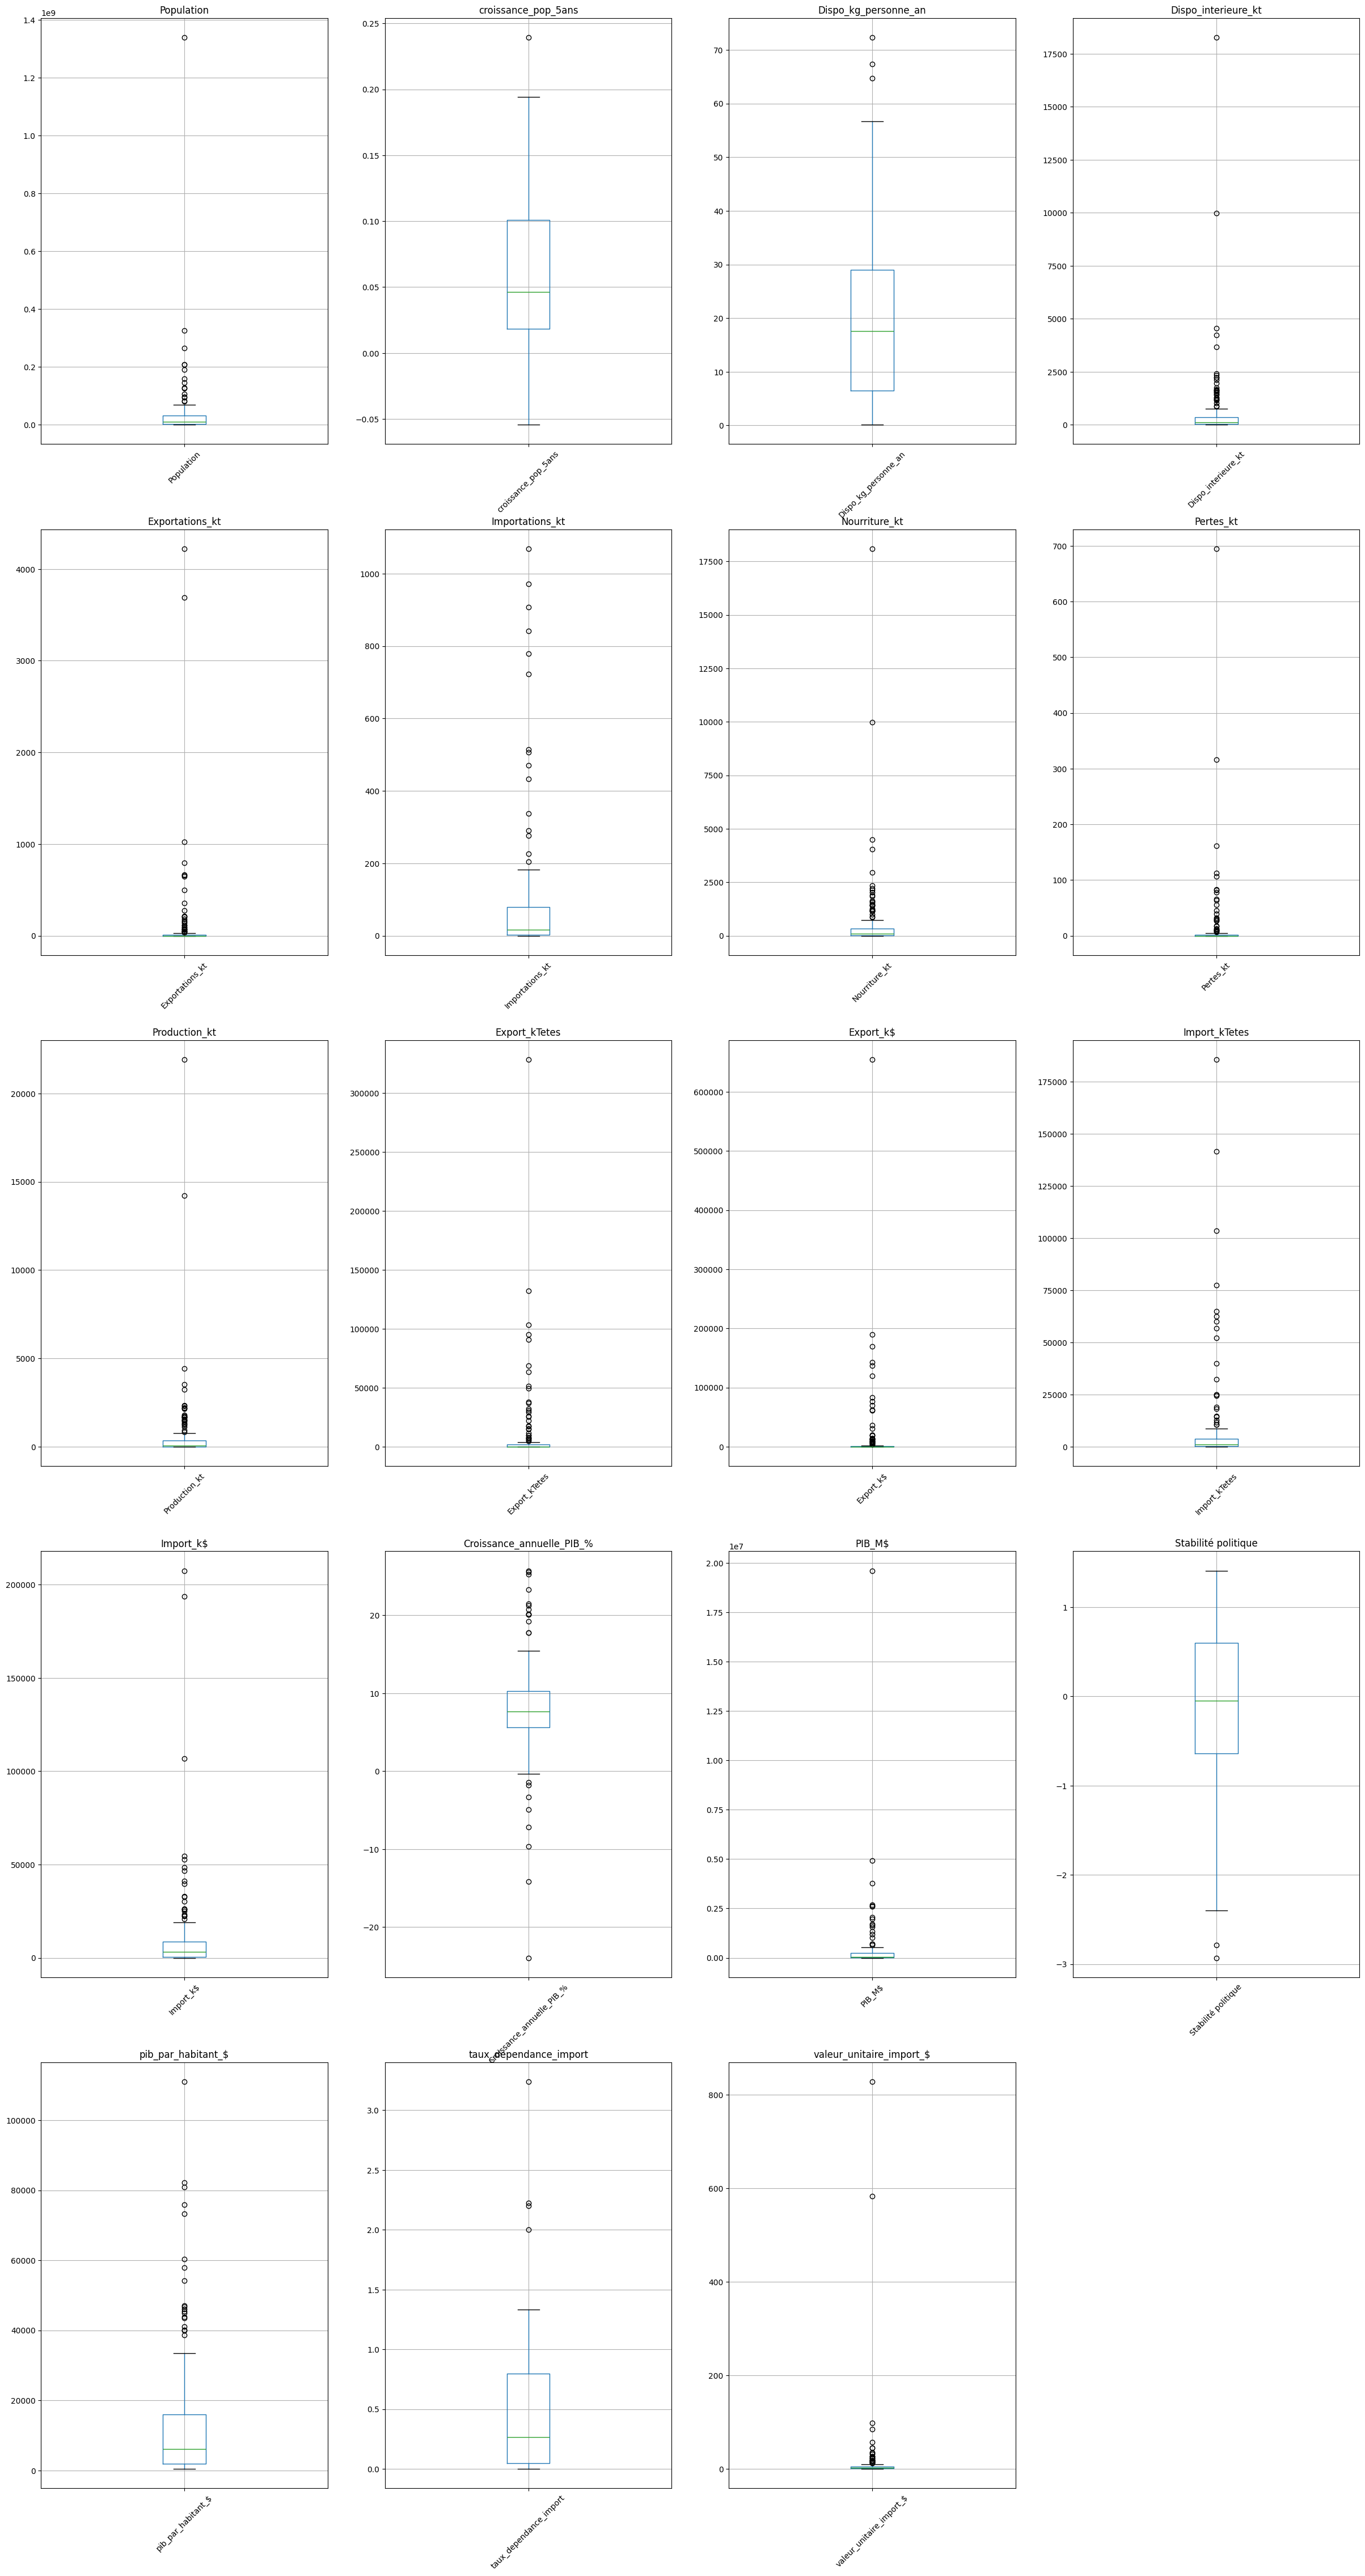

In [176]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(nrows=(len(numeric_cols)//3)+1, ncols=4, figsize=(30, 80))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    df_final.boxplot(column=col, ax=axes[i])
    axes[i].set_title(col)
    axes[i].tick_params(axis='x', rotation=45)

# Cache les axes vides
for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.show()


In [177]:
import numpy as np

In [178]:
from scipy import stats

def detecter_outliers_zscore(df, colonnes, seuil=3):
    resultats = []
    
    for col in colonnes:
        z_scores = np.abs(stats.zscore(df[col]))
        outliers_mask = z_scores > seuil
        nb_outliers = outliers_mask.sum()
        pct_outliers = (nb_outliers / len(df)) * 100
        
        if nb_outliers > 0:
            resultats.append({
                'Variable': col,
                'Nb_outliers': nb_outliers,
                'Pct_outliers': round(pct_outliers, 2),
                'Z_score_max': round(z_scores.max(), 2)
            })
    
    return pd.DataFrame(resultats)

resume_zscore = detecter_outliers_zscore(df_final, numeric_cols)
print(resume_zscore)


                     Variable  Nb_outliers  Pct_outliers  Z_score_max
0                  Population            1          0.65        11.18
1         croissance_pop_5ans            1          0.65         3.53
2        Dispo_kg_personne_an            1          0.65         3.30
3         Dispo_interieure_kt            2          1.31         9.81
4             Exportations_kt            2          1.31         8.79
5             Importations_kt            6          3.92         5.26
6               Nourriture_kt            2          1.31         9.89
7                   Pertes_kt            2          1.31        10.51
8               Production_kt            2          1.31         9.74
9               Export_kTetes            2          1.31         9.76
10                  Export_k$            1          0.65        10.69
11              Import_kTetes            3          1.96         7.50
12                  Import_k$            3          1.96         7.66
13  Croissance_annue

In [179]:
z_scores_df = df_final[numeric_cols].apply(lambda x: np.abs(stats.zscore(x)))
# Identifie les lignes avec au moins un z-score > 3
lignes_avec_outliers = (z_scores_df > 3).any(axis=1)
# Récap par pays
print(f"\n{'='*80}")
print(f"📊 RÉCAPITULATIF DES OUTLIERS PAR PAYS (z-score > 3)")
print(f"{'='*80}\n")
for pays in df_final[lignes_avec_outliers]['Zone'].unique():
    # Filtre les lignes du pays avec outliers
    mask_pays = (df_final['Zone'] == pays) & lignes_avec_outliers
    lignes_pays = df_final[mask_pays]
    
    print(f"🌍 {pays}")
    print("-" * 60)
    
    for idx in lignes_pays.index:
        # Trouve les colonnes outliers pour cette ligne
        z_scores_ligne = z_scores_df.loc[idx]
        cols_outliers = z_scores_ligne[z_scores_ligne > 3].index
        
        if len(cols_outliers) > 0:
    
            for col in cols_outliers:
                valeur = df_final.loc[idx, col]
                z_score = z_scores_ligne[col]
                print(f"• {col}: {valeur:.2f} (z-score: {z_score:.2f})")
            print()
    
    print()


📊 RÉCAPITULATIF DES OUTLIERS PAR PAYS (z-score > 3)

🌍 Afghanistan
------------------------------------------------------------
• Stabilité politique: -2.79 (z-score: 3.04)


🌍 Allemagne
------------------------------------------------------------
• Importations_kt: 842.00 (z-score: 4.05)
• Export_kTetes: 328450.00 (z-score: 9.76)
• Export_k$: 654322.00 (z-score: 10.69)
• Import_kTetes: 185661.00 (z-score: 7.50)
• Import_k$: 193759.00 (z-score: 7.12)


🌍 Arabie saoudite
------------------------------------------------------------
• Importations_kt: 722.00 (z-score: 3.40)


🌍 Belgique
------------------------------------------------------------
• Export_kTetes: 132204.00 (z-score: 3.76)
• Import_kTetes: 141743.00 (z-score: 5.64)
• Import_k$: 207538.00 (z-score: 7.66)
• taux_dependance_import: 2.22 (z-score: 3.50)


🌍 Brésil
------------------------------------------------------------
• Dispo_interieure_kt: 9982.00 (z-score: 5.21)
• Exportations_kt: 4223.00 (z-score: 8.79)
• Nourriture_

In [180]:
df_final = df_final[df_final['Stabilité politique']>=-1]

In [181]:
pays_a_exclure = ['Brésil','Ouzbékistan','Saint-Vincent-et-les Grenadines',"États-Unis d'Amérique"]

In [182]:
df_final = df_final[~df_final['Zone'].isin(pays_a_exclure)]

In [183]:
df_final

,Zone,Année,Population,croissance_pop_5ans,Dispo_kg_personne_an,Dispo_interieure_kt,Exportations_kt,Importations_kt,Nourriture_kt,Pertes_kt,...,Export_kTetes,Export_k$,Import_kTetes,Import_k$,Croissance_annuelle_PIB_%,PIB_M$,Stabilité politique,pib_par_habitant_$,taux_dependance_import,valeur_unitaire_import_$
1,Afrique du Sud,2017,57009756.0,0.061889,35.69,2118.0,63.0,514.0,2035.0,83.0,...,6090.0,7992.0,397.0,7394.0,17.791964,3.811367e+05,-0.28,6685.464789,0.242682,18.624685
2,Albanie,2017,2884169.0,-0.006757,16.36,47.0,0.0,38.0,47.0,0.0,...,0.0,0.0,4572.0,3266.0,9.767331,1.301973e+04,0.37,4514.205415,0.808511,0.714348
3,Algérie,2017,41389189.0,0.085187,6.38,277.0,0.0,2.0,264.0,13.0,...,0.0,0.0,195.0,19051.0,6.287893,1.700970e+05,-0.92,4109.696067,0.007220,97.697436
4,Allemagne,2017,82658409.0,0.018282,19.47,1739.0,646.0,842.0,1609.0,0.0,...,328450.0,654322.0,185661.0,193759.0,6.368624,3.763092e+06,0.57,45525.825010,0.484186,1.043617
6,Angola,2017,29816766.0,0.146103,10.56,319.0,0.0,277.0,315.0,2.0,...,0.0,0.0,1649.0,1814.0,20.766649,1.221239e+05,-0.39,4095.811665,0.868339,1.100061
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
217,Viet Nam,2017,94600648.0,0.042402,12.33,1206.0,1.0,291.0,1166.0,39.0,...,543.0,461.0,3280.0,9832.0,9.435232,2.813536e+05,0.21,2974.119228,0.241294,2.997561
219,Zambie,2017,16853599.0,0.129103,3.42,60.0,1.0,12.0,58.0,2.0,...,68.0,3863.0,6.0,3498.0,25.722423,2.590071e+04,0.14,1536.805838,0.200000,583.000000
220,Zimbabwe,2017,14236595.0,0.066382,4.68,76.0,0.0,6.0,67.0,3.0,...,211.0,653.0,403.0,2064.0,7.260694,2.204065e+04,-0.71,1548.168976,0.078947,5.121588
222,Émirats arabes unis,2017,9487203.0,0.031452,43.47,412.0,94.0,433.0,412.0,0.0,...,300.0,1012.0,1000.0,2297.0,5.757934,3.905168e+05,0.60,41162.480029,1.050971,2.297000


In [184]:
variables_a_garder = [
    'Zone',
    'Année',
    'Population',
    'croissance_pop_5ans',
    'Dispo_kg_personne_an',
    'Dispo_interieure_kt',
    'Import_k$',
    'Export_k$',
    'Production_kt',
    'valeur_unitaire_import_$', 
    'Croissance_annuelle_PIB_%',
    'pib_par_habitant_$',
    'Stabilité politique',
    'taux_dependance_import'
]

In [185]:
df_final = df_final[variables_a_garder]

In [186]:
df_final.to_csv('df_final.csv',index=False,encoding='utf-8-sig',sep=';',float_format='%.2f')